# Importing packages

In [1]:
import scimap as sm
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import sys
import yaml
from pathlib import Path
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib import colormaps
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.ndimage import gaussian_filter, binary_fill_holes, distance_transform_edt
from skimage import measure, morphology
from skimage.filters import threshold_otsu
from skimage.segmentation import find_boundaries
from shapely.geometry import Polygon
from shapely.geometry import Point
sys.path.append(os.path.abspath(".."))
rcParams['font.family'] = 'Arial'
from utils import extract_all_tumor_cores_otsu, extract_interaction

Running SCIMAP  2.2.11


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



# Call the local folders with the data

In [2]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])

# Read the adata object

In [3]:
adata = ad.read(results_dir / 'adata.h5ad')

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



# Define cell category column, cell order, and cell colors

In [4]:
##get the color scheme
conditions = [
    adata.obs['cell_type'] == 'CD4+_T_cells',
    adata.obs['cell_type'] == 'CD8+_T_cells',
    adata.obs['cell_type'] == "Treg_T_cells",
    adata.obs['cell_type'] == 'NK_cells',
    adata.obs['cell_type'] == "M1_macrophages",
    adata.obs['cell_type'] == "M2_macrophages",
    adata.obs['cell_type'] == "M1_M2_macrophages",
    adata.obs['cell_type'] == "B_cells",
    adata.obs['cell_type'] == 'Plasma_cells',
    adata.obs['cell_type'] == 'DCs',
    adata.obs['cell_type'] == 'Granulocytes',
    adata.obs['cell_type'] == 'Mast_cells',
    adata.obs['cell_type'] == 'MDSCs',
    adata.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata.obs['cell_type'] == 'Endothelial_cells',
    adata.obs['cell_type'] == 'Actin+_cells',
    adata.obs['cell_type'] == 'Tumor_cells',
    adata.obs['cell_type'] == 'Epithelial_cells',
    adata.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

myeloid_color = {
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

lymphoid_color = {
    "B cells": "#FFFF00",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "Treg cells": "#AAFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",  
}

#all cell types order
all_ct_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells", "DCs", 
                "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  
                "MDSCs", "Lymphatic endothelial cells", "Endothelial cells", "Epithelial cells", "NFC", "Actin+ cells", "Tumor cells"]
lymphoid_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells"]
myeloid_order = ["DCs", "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  "MDSCs"]

In [ ]:
#calculate cell type proportiosn per site
counts_patient = adata.obs.groupby(['patient_ID', 'cell_category']).size().unstack(fill_value=0)
#turn them to percentages
counts_patient_percentage = counts_patient.div(counts_patient.sum(axis=1), axis=0) * 100
#sort order
counts_patient_percentage = counts_patient_percentage[all_ct_order]
#select only lymphoid cells
counts_lymphoid = counts_patient_percentage[lymphoid_color.keys()]
counts_lymphoid = counts_lymphoid[lymphoid_order]
#select only myeloid cells
counts_myeloid = counts_patient_percentage[myeloid_color.keys()]
counts_myeloid = counts_myeloid[myeloid_order]

In [ ]:
# Ensure consistent font & style
plt.rcParams['font.family'] = 'Arial'

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

# --- All cells ---
cell_category_perc.plot(
    kind="barh", 
    stacked=True, 
    color=cell_category_color, 
    ax=axes[0], 
    edgecolor='black', 
    linewidth=0.2
)
axes[0].set_title("All cell types", fontsize=18)
axes[0].set_xlabel("Cells [%]")
axes[0].set_ylabel("Patient")
axes[0].legend().set_visible(False)
axes[0].grid(False)

# --- Lymphoid ---
counts_lymphoid.plot(
    kind="barh", 
    stacked=True, 
    color=lymphoid_color, 
    ax=axes[1], 
    edgecolor='black', 
    linewidth=0.2
)
axes[1].set_title("Lymphoid cells", fontsize=18)
axes[1].set_xlabel("Cells [%]")
axes[1].set_ylabel("")  # remove duplicate y-axis label
axes[1].legend().set_visible(False)
axes[1].grid(False)

# --- Myeloid ---
counts_myeloid.plot(
    kind="barh", 
    stacked=True, 
    color=myeloid_color, 
    ax=axes[2], 
    edgecolor='black', 
    linewidth=0.2
)
axes[2].set_title("Myeloid cells", fontsize=18)
axes[2].set_xlabel("Cells [%]")
axes[2].set_ylabel("")  # remove duplicate y-axis label
axes[2].legend().set_visible(False)
axes[2].grid(False)

# Formatting ticks
for ax in axes:
    ax.tick_params(axis='y', labelsize=8)
    for tick in ax.get_yticklabels():
        tick.set_ha('right')
        tick.set_fontsize(20)
#make y-axis title bigger
axes[0].yaxis.label.set_size(20)
#x-axis title bigger
fig.axes[0].xaxis.label.set_size(20)
fig.axes[1].xaxis.label.set_size(20)
fig.axes[2].xaxis.label.set_size(20)
plt.tight_layout()
plt.savefig(results_dir / "poster_combined_barplot.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.patches as mpatches

# Get handles and labels
handles, labels = axes[0].get_legend_handles_labels()

# Extract colors from each BarContainer
colors = [h.patches[0].get_facecolor() for h in handles]

# Sort labels & colors together alphabetically
labels, colors = zip(*sorted(zip(labels, colors), key=lambda x: x[0]))

# Make circular legend markers
circle_handles = [
    mpatches.Circle((0, 0), radius=5, facecolor=c, edgecolor="black")
    for c in colors
]

# Create a new figure just for the legend
fig_legend = plt.figure(figsize=(10, 3))
fig_legend.legend(
    circle_handles,
    labels,
    loc="center",
    ncol=7,          # adjust columns if needed
    frameon=False,
    fontsize=12,
    handlelength=1,
    handletextpad=0.5
)

plt.savefig(results_dir / "poster_combined_barplot_legend.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


# Infiltration Function

# Run Tumor core detection function

In [ ]:
adata.obs['distance_to_tumor'] = np.nan
adata.obs['n_cores'] = np.nan
adata.obs['tumor_area'] = np.nan
for exp in adata.obs['patient_exp'].unique():
    print(f"Processing experiment: {exp}")
    # Subset adata for the current experiment
    adata_exp = adata[adata.obs['patient_exp'] == exp]
    polygons, distances, n_cores, tumor_area, on_contour_flags = extract_all_tumor_cores_otsu(adata_exp, plot=True, save=True, sigma=1, results_dir=results_dir)
    adata.obs.loc[adata_exp.obs.index, 'distance_to_tumor'] = distances
    adata.obs.loc[adata_exp.obs.index, 'n_cores'] = n_cores
    adata.obs.loc[adata_exp.obs.index, 'tumor_area'] = tumor_area
    adata.obs.loc[adata_exp.obs.index, 'tumor_edge'] = on_contour_flags

conditions = [
    (adata.obs['distance_to_tumor'] == 0) & (adata.obs['tumor_edge'] == False),
    ((adata.obs['distance_to_tumor'] == 0) & (adata.obs['tumor_edge'] == True)) |
    ((adata.obs['distance_to_tumor'] > 0) & (adata.obs['distance_to_tumor'] <= 400)),
    (adata.obs['distance_to_tumor'] > 400)
]

choices = ['Core (0μm)', 'Edge (0-100μm)', 'Distal (100+μm)']

adata.obs['tumor_proximity'] = np.select(conditions, choices, default='Distal')

adata.obs['tumor_proximity'] = pd.Categorical(adata.obs['tumor_proximity'], categories=['Core (0μm)', 'Edge (0-100μm)', 'Distal (100+μm)'], ordered=True)

In [ ]:
for patient_exp in adata.obs['patient_exp'].unique():
    adata_select = adata[adata.obs['patient_exp'] == patient_exp]
    coords = adata_select.obsm["spatial"]    # Nx2 array (x, y)
    x, y = coords[:, 0], coords[:, 1]
    categories = adata_select.obs["cell_category"]
    unique_cats = categories.unique()
    
    # --- Map categories to palette ---
    # `cell_category_color` should be a dict like {"cat1": "#hex", ...}
    colors = categories.map(cell_category_color)
    
    # --- Plot ---
    plt.figure(figsize=(10, 8))
    plt.scatter(
        x, y,
        c=colors,
        s=15,           # equivalent to spot_size
        alpha=0.8,
        linewidths=0,
    )
    
    plt.gca().invert_yaxis()
    
    
    # --- Remove frame/axes if desired ---
    plt.axis("off")
    
    #plt title
    plt.title(f'{patient_exp}', fontsize=16)
    
    # --- Legend ---
    for cat in unique_cats:
        plt.scatter([], [], c=cell_category_color[cat], label=cat, s=60, alpha=0.8)
    plt.legend(frameon=False, markerscale=1.5, bbox_to_anchor=(1, 1),   # move legend outside plot
        loc='upper left')
    
    plt.savefig(
    f"/Users/jawadalaaedeen/Desktop/PhD/NMC/results/poster_{patient_exp}_spatial_plot.svg",
    dpi=300,
    bbox_inches="tight" 
    )
    
    plt.show()


In [ ]:
coords = adata_select.obsm["spatial"]
x, y = coords[:, 0], coords[:, 1]


categories = adata_select.obs["tumor_proximity"]
unique_cats = categories.unique()

#color map
color_dict = {
    "Core (0μm)": "#D73027",      # magenta
    "Edge (0-100μm)": "#1A9850",   # blue
    "Distal (100+μm)": "#4575B4"   # yellow
}


plt.figure(figsize=(10, 10))

for cat in unique_cats:
    mask = categories == cat
    plt.scatter(
        x[mask], y[mask],
        s=15,
        alpha=0.8,
        linewidths=0,
        color=color_dict[cat],
        label=cat
    )

plt.gca().invert_yaxis()
plt.axis("off")
plt.title("NMC_7_ROI13", fontsize=16)

handles = [
    Line2D([0], [0], marker='o', color='w', label=cat,
           markerfacecolor=color_dict[cat], markersize=8)
    for cat in color_dict.keys()
]

plt.legend(handles=handles, frameon=False, markerscale=1.5,
           bbox_to_anchor=(1, 1), loc='upper left')


plt.savefig(
    "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/poster_NMC7_ROI13_spatial_plot_core.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Calculate Infiltration of only immune cells

In [79]:
excluded_cell_types = ["Endothelial cells", "Lymphatic endothelial cells", "NFC", "Epithelial cells", "Actin+ cells", "Tumor cells"]

# My method of infiltration

In [ ]:
infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('cell_category', 'count')
).reset_index()
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]
#total infiltrated cells per patient
infiltration["total_cells"] = infiltration.groupby('patient_exp')['infiltration'].transform('sum')
infiltration['percentage'] = (infiltration['infiltration'] / infiltration['total_cells']) * 100
infiltration.to_csv(results_dir/'NMC_infiltration_percentage.csv')

#  Plot Infiltration

In [ ]:
pivot_df = infiltration.pivot_table(
    index="patient_exp",
    columns="cell_category",
    values="percentage",
    aggfunc="sum"
)

# --- Define your custom order ---
myeloid_lymphoid_category_order = [
    "MDSCs",
    "M2 macrophages",
    "M1 macrophages",
    "M1/M2 macrophages",
    "Granulocytes",
    "Mast cells",
    "DCs",
    "B cells",
    "PCs",
    "NK cells",
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg cells",

]  

# --- Define custom colors ---
myeloid_lymphoid_category_color = {
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000FF",
    "Treg cells": "#AAFF7F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

# Reindex columns to your preferred order (ignore missing safely)
pivot_df = pivot_df.reindex(columns=[c for c in myeloid_lymphoid_category_order if c in pivot_df.columns])

colors = [myeloid_lymphoid_category_color[c] for c in pivot_df.columns]

# --- Plot (horizontal stacked barplot) ---
ax = pivot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10,10),   # make taller since now samples are on y-axis
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.xlabel("Infiltrating Cells [%]", fontsize=20)
plt.ylabel("Sample", fontsize=20)
plt.title("Proportions of infiltrating immune cells", fontsize=20)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")

plt.savefig(results_dir / "poster_infiltration_horizontal.svg", format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()



/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/1369739136.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/1369739136.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/1369739136.py:12: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



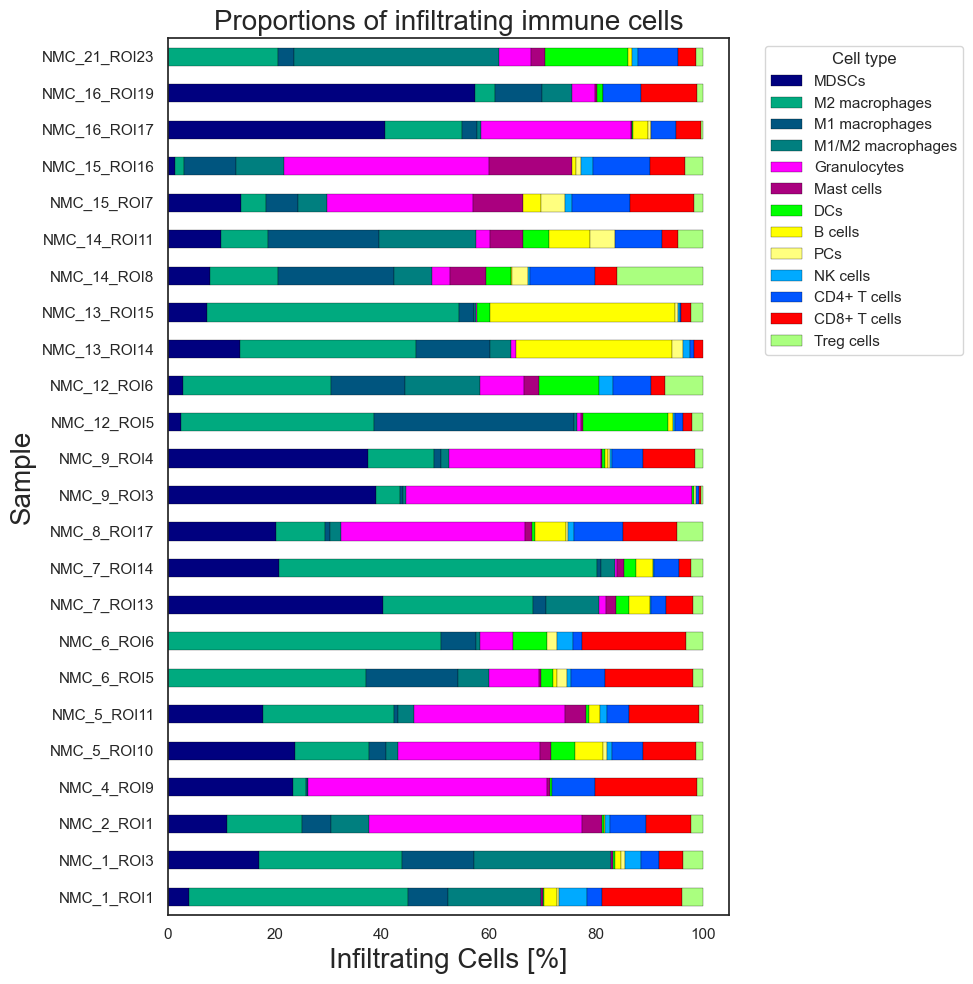

In [181]:
excluded_cell_types = ["Endothelial cells", "Lymphatic endothelial cells", "NFC", "Epithelial cells", "Actin+ cells", "Tumor cells"]

infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('cell_category', 'count')
).reset_index()
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]
#total infiltrated cells per patient
infiltration["total_cells"] = infiltration.groupby('patient_exp')['infiltration'].transform('sum')
infiltration['percentage'] = (infiltration['infiltration'] / infiltration['total_cells']) * 100

pivot_df = infiltration.pivot_table(
    index="patient_exp",
    columns="cell_category",
    values="percentage",
    aggfunc="sum"
)

# --- Define your custom order ---
myeloid_lymphoid_category_order = [
    "MDSCs",
    "M2 macrophages",
    "M1 macrophages",
    "M1/M2 macrophages",
    "Granulocytes",
    "Mast cells",
    "DCs",
    "B cells",
    "PCs",
    "NK cells",
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg cells",

]  

# --- Define custom colors ---
myeloid_lymphoid_category_color = {
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000FF",
    "Treg cells": "#AAFF7F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

# Reindex columns to your preferred order (ignore missing safely)
pivot_df = pivot_df.reindex(columns=[c for c in myeloid_lymphoid_category_order if c in pivot_df.columns])

colors = [myeloid_lymphoid_category_color[c] for c in pivot_df.columns]

# --- Plot (horizontal stacked barplot) ---
ax = pivot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10,10),   # make taller since now samples are on y-axis
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.xlabel("Infiltrating Cells [%]", fontsize=20)
plt.ylabel("Sample", fontsize=20)
plt.title("Proportions of infiltrating immune cells", fontsize=20)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")


plt.tight_layout()
plt.show()


In [182]:
# get the metadata of survival
df = adata.obs[["patient_exp", "patient_ID", "survival_time_months"]].copy()

# ensure patient_exp is categorical
df["patient_exp"] = df["patient_exp"].astype("category")

# sort according to the category order of patient_exp
df = df.sort_values("patient_exp")

# keep only one row per patient_exp
df_unique = df.drop_duplicates(subset="patient_exp", keep="first")

pivot_df["survival_time_months"] = df_unique["survival_time_months"].values

pivot_df["patient_ID"] = df_unique["patient_ID"].values


In [183]:
granulocyte_infiltration = pivot_df[["patient_ID", "survival_time_months", "Granulocytes"]].copy()
#average them per patient
granulocyte_infiltration = granulocyte_infiltration.groupby("patient_ID").median().reset_index()
granulocyte_infiltration
#anything above 30% is high infiltration
granulocyte_infiltration['infiltration_group'] = np.where(granulocyte_infiltration['Granulocytes'] > 30, 'High', 'Low')
granulocyte_infiltration["event"] = 1
#remove patient 1 because outliers
granulocyte_infiltration = granulocyte_infiltration[granulocyte_infiltration["patient_ID"] != "NMC_1"]

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/2161652080.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



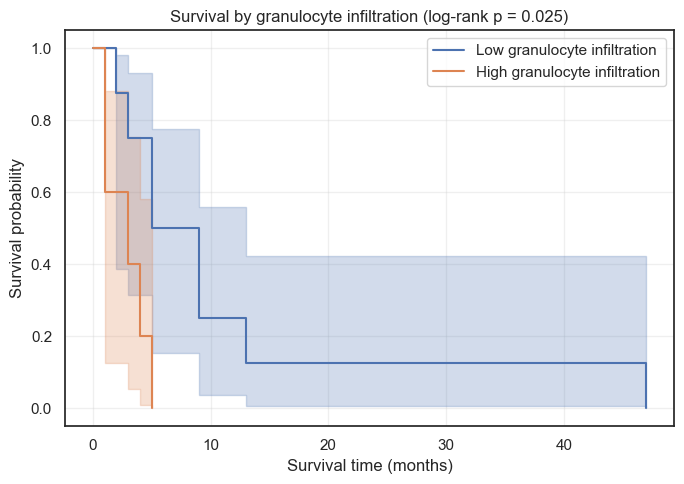

Log-rank test p-value: 0.02545402684301771


In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Make sure event is int/bool: 1=dead, 0=censored
# df["event"] = df["event"].astype(int)

# Split groups
low = granulocyte_infiltration[granulocyte_infiltration["infiltration_group"] == "Low"]
high = granulocyte_infiltration[granulocyte_infiltration["infiltration_group"] == "High"]

kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

plt.figure(figsize=(7, 5))

# --- LOW group ---
kmf_low.fit(
    durations=low["survival_time_months"],
    event_observed=low["event"],
    label="Low granulocyte infiltration"
)
ax = kmf_low.plot(ci_show=True, show_censors=True)

# --- HIGH group ---
kmf_high.fit(
    durations=high["survival_time_months"],
    event_observed=high["event"],
    label="High granulocyte infiltration"
)
kmf_high.plot(ax=ax, ci_show=True, show_censors=True)

# --- Log-rank test ---
results = logrank_test(
    low["survival_time_months"],
    high["survival_time_months"],
    event_observed_A=low["event"],
    event_observed_B=high["event"]
)
p_value = results.p_value

# --- Cosmetics ---
plt.title(f"Survival by granulocyte infiltration (log-rank p = {p_value:.3f})")
plt.xlabel("Survival time (months)")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
print("Log-rank test p-value:", p_value)


In [186]:
macrophages_infiltration = pivot_df[["patient_ID", "survival_time_months", "M2 macrophages"]].copy()
#average them per patient
macrophages_infiltration = macrophages_infiltration.groupby("patient_ID").median().reset_index()
#anything above 30% is high infiltration
macrophages_infiltration['infiltration_group'] = np.where(macrophages_infiltration['M2 macrophages'] > 30, 'High', 'Low')
macrophages_infiltration["event"] = 1
#remove patient 1 because outliers
macrophages_infiltration = macrophages_infiltration[macrophages_infiltration["patient_ID"] != "NMC_1"]
macrophages_infiltration

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/3235819371.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



cell_category,patient_ID,survival_time_months,M2 macrophages,infiltration_group,event
1,NMC_2,1.0,14.024390,Low,1
2,NMC_4,3.0,2.409147,Low,1
3,NMC_5,9.0,19.246605,Low,1
4,NMC_6,5.0,44.051323,High,1
5,NMC_7,9.0,43.663619,High,1
6,NMC_8,4.0,9.060956,Low,1
7,NMC_9,1.0,8.402476,Low,1
8,NMC_12,47.0,32.004831,High,1
9,NMC_13,5.0,39.997753,High,1
10,NMC_14,2.0,10.791659,Low,1


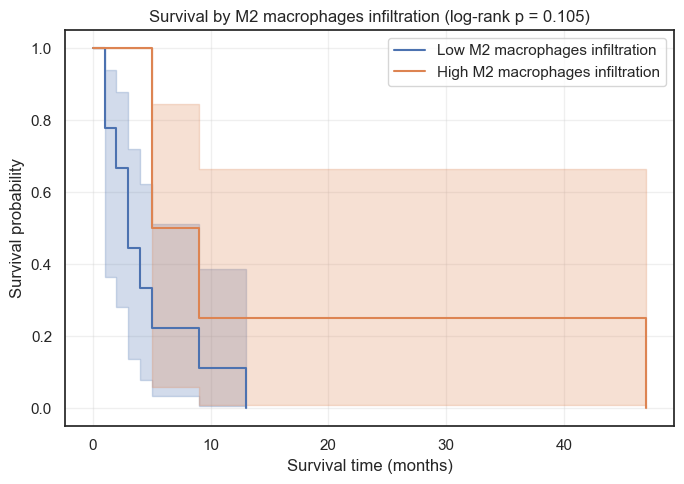

Log-rank test p-value: 0.10545053777393118


In [187]:
low = macrophages_infiltration[macrophages_infiltration["infiltration_group"] == "Low"]
high = macrophages_infiltration[macrophages_infiltration["infiltration_group"] == "High"]

kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

plt.figure(figsize=(7, 5))

# --- LOW group ---
kmf_low.fit(
    durations=low["survival_time_months"],
    event_observed=low["event"],
    label="Low M2 macrophages infiltration"
)
ax = kmf_low.plot(ci_show=True, show_censors=True)

# --- HIGH group ---
kmf_high.fit(
    durations=high["survival_time_months"],
    event_observed=high["event"],
    label="High M2 macrophages infiltration"
)
kmf_high.plot(ax=ax, ci_show=True, show_censors=True)

# --- Log-rank test ---
results = logrank_test(
    low["survival_time_months"],
    high["survival_time_months"],
    event_observed_A=low["event"],
    event_observed_B=high["event"]
)
p_value = results.p_value

# --- Cosmetics ---
plt.title(f"Survival by M2 macrophages infiltration (log-rank p = {p_value:.3f})")
plt.xlabel("Survival time (months)")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

print("Log-rank test p-value:", p_value)


## Spatial Interaction

In [166]:
sm.tl.spatial_interaction(adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_category",
                         method='delaunay',
                         permutation=300,
                         cond_counts_threshold= 3,
                         imageid='patient_exp',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['NMC_14_ROI11']
Categories (1, object): ['NMC_14_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI16']
Categories (1, object): ['NMC_15_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI7']
Categories (1, object): ['NMC_15_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_1_ROI3']
Categories (1, object): ['NMC_1_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_16

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_8_ROI17']
Categories (1, object): ['NMC_8_ROI17']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_5_ROI11']
Categories (1, object): ['NMC_5_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_6_ROI5']
Categories (1, object): ['NMC_6_ROI5']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


...

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_4_ROI9']
Categories (1, object): ['NMC_4_ROI9']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_13_ROI14']
Categories (1, object): ['NMC_13_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_7_ROI14']
Categories (1, object): ['NMC_7_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_7_ROI13']
Categories (1, object): ['NMC_7_ROI13']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_6_ROI6']
Categories (1, object): ['NMC_6_ROI6']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_12_ROI6']
Categories (1, object): ['NMC_12_ROI6']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results


AnnData object with n_obs × n_vars = 587448 × 144
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', 

# Extract Spatial Interactions Function

In [167]:
excluded_cell_types = ["Endothelial cells", "Lymphatic endothelial cells", "NFC", "Epithelial cells", "Tumor cells", "Actin+ cells"]

# Immune - Tumor Interaction

In [ ]:
interaction = extract_interaction(adata, 
                                  selected_cell_type="Tumor cells", 
                                  excluded_cell_types=excluded_cell_types, 
                                  direction="to", 
                                  cells_threshold=15, 
                                  save_data=True,
                                  results_dir=results_dir)
interaction

# Immune - Tumor Interaction

# Tumor - Immune Interaction

In [ ]:
interaction = extract_interaction(adata,
                                    selected_cell_type="Tumor cells",
                                    excluded_cell_types=excluded_cell_types, 
                                    direction="from", 
                                    cells_threshold=15, 
                                    save_data=True,
                                    results_dir=results_dir)
interaction

# MDSCs - Other Immune

In [ ]:
interaction = extract_interaction(adata,
                                    selected_cell_type="MDSCs", 
                                    excluded_cell_types=excluded_cell_types + ["MDSCs"], 
                                    direction="from", 
                                    cells_threshold=15, 
                                    save_data=True,
                                    results_dir=results_dir)
interaction

In [ ]:
interaction = extract_interaction(adata,
                                    selected_cell_type="CD8+_T_cells", 
                                    excluded_cell_types=excluded_cell_types + ["CD8+_T_cells", "CD4+_T_cells"], 
                                    direction="from", 
                                    cells_threshold=15, 
                                    save_data=True)

interaction = extract_interaction(adata,
                                    selected_cell_type="CD8+_T_cells", 
                                    excluded_cell_types=excluded_cell_types + ["CD8+_T_cells", "CD4+_T_cells"], 
                                    direction="to", 
                                    cells_threshold=15, 
                                    save_data=True)

interaction

# Chiara method of infiltration

In [ ]:
#Calculate infiltration to the tumor with COZI
infiltration = adata.uns['scimap_delaunay_conditional_zscore']
infiltration.index = infiltration["phenotype"] + "-" + infiltration["neighbour_phenotype"]
infiltration= infiltration.drop(columns=["phenotype", "neighbour_phenotype"])
infiltration = infiltration.filter(like='cond_cells_percentage', axis=1)
infiltration.columns = infiltration.columns.str.replace('cond_cells_percentage_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "patient_ID").loc[:,["exp_name", "patient_ID", "patient_exp"]].drop_duplicates().reset_index(drop=True)
infiltration = infiltration[ordered_columns["patient_exp"]]
infiltration.columns = ordered_columns["patient_exp"].values
#only keep index that has Tumor-cells
infiltration = infiltration[infiltration.index.str.contains("-Tumor_cells")]
#make data in long format
infiltration_long = infiltration.reset_index().melt(id_vars='index', var_name='patient_exp', value_name='cond_cells_percentage')
infiltration_long.rename(columns={'index': 'cell_type'}, inplace=True)
#make second column the first column
infiltration_long = infiltration_long[['patient_exp', 'cell_type', 'cond_cells_percentage']]
infiltration_long['cell_type'] = infiltration_long['cell_type'].str.replace('-Tumor_cells', '', regex=False)
total_cells = adata.obs.groupby(["patient_exp", "cell_type"]).size().reset_index(name='total_cells')
infiltration_long = infiltration_long.merge(total_cells, on=['patient_exp', 'cell_type'], how='left')
infiltration_long.loc[infiltration_long["total_cells"] < 15, "cond_cells_percentage"] = np.nan
infiltration_long = infiltration_long.drop(columns=["total_cells"])
# infiltration_long["total_cells"] = adata.obs.groupby(["patient_exp", "cell_type"])["cell_type"].count().values
# #make distance_to_tumor NA for any row with less than 20 total_cells
# infiltration_long.loc[infiltration_long["total_cells"] <= 15, "cell_type"] = np.nan
# infiltration_long = infiltration_long[~infiltration_long["cell_type"].isin(["Tumor_cells"])]
#take out stromal cells and tumor cells
infiltration_long = infiltration_long[~infiltration_long["cell_type"].isin(excluded_cell_types)]
#save infiltration_long
infiltration_long.to_csv(results_dir / "NMC_cozi_infiltration.csv", index=False)

# Spatial distance

In [ ]:
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

In [95]:
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

# --- Data prep ---
distances = adata.uns['spatial_distance']
distances["cell_category"] = adata.obs['cell_category'].values
distances = distances.loc[:, ["cell_category", "Tumor cells"]]
distances["Tumor cells"] = distances["Tumor cells"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["Tumor cells"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Counts for each cell type
counts = distances["cell_category"].value_counts().reindex(order)

In [ ]:
# --- Plot ---
fig, ax_violin = plt.subplots(figsize=(16, 16))

# Distance violinplot
sns.violinplot(
    data=distances,
    x="Tumor cells",
    y="cell_category",
    order=order,
    palette=cell_category_color,   # <--- your custom colors here
    scale="width",
    ax=ax_violin,
    log_scale=True
)
#increase size of y-axis labels 
ax_violin.tick_params(axis='y', labelsize=20)
# Axis labels
ax_violin.set_xlabel(
    "Distance to the closest tumor cell (log10µm)",
    fontsize=20
)
ax_violin.set_ylabel(
    "All Cell types",
    fontsize=20
)

# Add counts on the right side
for i, cell_category in enumerate(order):
    count_val = counts[cell_category]
    ax_violin.text(
        x=ax_violin.get_xlim()[1] * 1.09,
        y=i,
        s=f"{count_val:,}",
        va="center",
        ha="left",
        fontfamily="Arial",
        fontsize = 18
    )

# Add label for counts (once)
ax_violin.text(
    x=ax_violin.get_xlim()[1] * 1.03,
    y=len(order) + 0.5,
    s="Cell count",
    va="bottom", ha="left",
    fontfamily="Arial", 
    fontsize = 18
)

# Remove right/top spines
sns.despine(ax=ax_violin, right=True, top=True)

#save svg figure
plt.savefig(results_dir / "poster_distance_to_tumor_cells.svg", format='svg', bbox_inches='tight', dpi = 300)

plt.tight_layout()
plt.show()



In [ ]:
#average cell type per patient per cell type
distances["patient_exp"] = adata.obs['patient_exp'].values
distances_average = distances.groupby(['patient_exp', 'cell_category'])['Tumor cells'].median().reset_index()
#zscore per patient
distances_average['zscore'] = distances_average.groupby('patient_exp')['Tumor cells'].transform(lambda x: (x - x.mean()) / x.std())
distances_average

In [ ]:
#resolution is 0.17 microns per pixel
distances_um = distances.copy()
distances_um["Tumor cells"] = distances_um["Tumor cells"] * 0.17

# Pick the cell types you want to compare
cell_types = adata.obs.cell_category.unique()

plt.figure(figsize=(10,6))  # bigger figure

highlight = ["MDSCs", "M2 macrophages", "CD8+ T cells", "Tumor cells", "B cells", "M1 macrophages", "CD4+ T cells"]
for ct in adata.obs.cell_category.unique():
    dists = distances_um[distances_um["cell_category"] == ct]["Tumor cells"].dropna().values
    sorted_vals = np.sort(dists)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    
    if ct in highlight:
        plt.plot(sorted_vals, cdf, label=ct, linewidth=3, 
                 color=cell_category_color.get(ct, "black"))
    else:
        plt.plot(sorted_vals, cdf, linewidth=1, color="lightgrey", alpha=0.5)


plt.xlabel("Distance to nearest tumor cell (µm)", fontsize=14)
plt.ylabel("Cumulative fraction of cells", fontsize=14)
plt.title("Cumulative Distribution of distance to tumor cells", fontsize=16)


legend_order = ["Tumor cells", "MDSCs", "M2 macrophages", 
                "M1 macrophages", "CD8+ T cells",
                "CD5+ T cells", "B cells"]

# after plotting everything:
handles, labels = plt.gca().get_legend_handles_labels()

# reorder according to legend_order
order = [labels.index(l) for l in legend_order if l in labels]

plt.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    bbox_to_anchor=(1.05, 1), loc="upper left",
    frameon=False, fontsize=12
)

plt.grid(alpha=0.3)

plt.savefig(results_dir / "poster_cdf.svg", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [ ]:
distances_ht = distances.copy()
distances_ht["patient_exp"] = adata.obs['patient_exp'].values
distances_ht = distances_ht.loc[:, ["cell_category", "Tumor cells", "patient_exp"]]
#write distances_ht as csv
distances_ht.to_csv(results_dir / "distances_to_tumor_cells_by_patient.csv", index=False)
#pivot table
distances_ht_pivot = distances_ht.pivot_table(index='cell_category', columns='patient_exp', values='Tumor cells', aggfunc='median')
#min max every patient
distances_ht_pivot = distances_ht_pivot.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
distances_ht_pivot

In [4]:
adata_unified = sc.read_h5ad(results_dir / 'adata_unified.h5ad')
adata_unified.X = np.arcsinh(adata_unified.X / 5)

In [ ]:
for patient_exp in adata_unified.obs["patient_exp"].unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp, :]
    plot = sc.pl.stacked_violin(adata_select, adata_select.var_names, groupby='cell_type', cmap='coolwarm', use_raw=False, density_norm='area', figsize=(15, 8), return_fig=True)
    plot.add_totals()
    axes = plot.get_axes()
    group_ax = axes['group_extra_ax']
    for text in group_ax.texts:
        current_pos = text.get_position()
        text.set_position((current_pos[0] + 7, current_pos[1]+4))
    axes['color_legend_ax'].set_position([0.89, 0.80, 0.1, 0.05])
    fig = axes['mainplot_ax'].figure
    #title
    fig.suptitle(f'Marker expression in {patient_exp}', fontsize=16)

In [ ]:
#Calculate percentages per patient_exp of each cell type with distances_to_tumor = 0 
infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('distance_to_tumor', 'count')
).reset_index()
#get the percentages
infiltration['percentage'] = infiltration['infiltration'] / infiltration['total_cells']
#cell type with less than 15 cells per patient should have na PERCENTAGe
infiltration.loc[infiltration['total_cells'] <= 15, 'percentage'] = np.nan
#Filter out Tumor_cells, Endothelial_cells, Lymphatic_endothelial_cells, Epithelial_cells, Actin+_cells, and NFC
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]
#add -Tumor_cells to cell type then make it categorical 
#save the infiltration to desktop 
infiltration.to_csv(results_dir/'NMC_infiltration_percentage.csv')

In [ ]:
infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('distance_to_tumor', 'count')
).reset_index()

excluded_cell_types = ['Tumor cells', 'Endothelial cells', 'Lymphatic endothelial cells', 'Epithelial cells', 'Actin+ cells', 'NFC']
#filter out excluded cell types
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]

#calculate total of cell types per patient in infiltration 
infiltration["total_infiltrated"] = infiltration.groupby("patient_exp")["infiltration"].transform("sum")
infiltration["percentage"] = infiltration["infiltration"] / infiltration["total_infiltrated"]

In [ ]:

# --- Prepare data ---
infiltration["percentage"] = infiltration["percentage"].fillna(0)
#make it actually a percentag
infiltration["percentage"] = infiltration["percentage"] * 100

pivot_df = infiltration.pivot_table(
    index="patient_exp",
    columns="cell_category",
    values="percentage",
    aggfunc="sum"
)

# --- Define your custom order ---
cell_order = [
    "MDSCs",
    "M2 macrophages",
    "M1 macrophages",
    "M1/M2 macrophages",
    "Granulocytes",
    "Mast cells",
    "DCs",
    "B cells",
    "PCs",
    "NK cells",
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg cells",

]  # adjust as you like

# Reindex columns to your preferred order (ignore missing safely)
pivot_df = pivot_df.reindex(columns=[c for c in cell_order if c in pivot_df.columns])

# --- Define custom colors ---
cell_category_color = {
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000FF",
    "Treg cells": "#AAFF7F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

colors = [cell_category_color[c] for c in pivot_df.columns]

# --- Plot ---
ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.ylabel("Infiltrating Cells [%]", fontsize=16)
plt.xlabel("Sample", fontsize = 20)
plt.title("Proportions of infiltrating immune cells")
plt.xticks(rotation=45, ha="right")

#make y-axis title bigger
ax.yaxis.label.set_size(20)
#x-axis title bigger
ax.xaxis.label.set_size(20)

ax.title.set_size(20)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")

plt.savefig(results_dir / "poster_infiltration.svg", format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()


In [ ]:
# --- Plot (horizontal stacked barplot) ---
ax = pivot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10,12),   # make taller since now samples are on y-axis
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.xlabel("Infiltrating Cells [%]", fontsize=16)
plt.ylabel("Sample", fontsize=16)
plt.title("Proportions of infiltrating immune cells", fontsize=16)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")

plt.savefig(results_dir / "poster_infiltration_horizontal.svg", format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()


In [232]:
#Let's read adata unified
adata_unified = sc.read_h5ad(results_dir / 'adata_unified.h5ad')
adata_unified.X = np.arcsinh(adata_unified.X / 5)

In [233]:
tumor_functional_markers = [
    # Proliferation
    "KI67", "PCNA", "P16", "P16 1", "P53",
    
    # Survival / Apoptosis
    "BCL2", "CLEAVEDPARP1",
    
    # Oncogenic antigens
    "PRAME", "ERBB2",
    
    # Immune evasion / Checkpoints
    "CD274", "CD274 1", "CD276", "VISTA", "GALECTIN9", "HLAABC", "HLADR"
]

##get the color scheme
conditions = [
    adata_unified.obs['cell_type'] == 'CD4+_T_cells',
    adata_unified.obs['cell_type'] == 'CD8+_T_cells',
    adata_unified.obs['cell_type'] == "Treg_T_cells",
    adata_unified.obs['cell_type'] == 'NK_cells',
    adata_unified.obs['cell_type'] == "M1_macrophages",
    adata_unified.obs['cell_type'] == "M2_macrophages",
    adata_unified.obs['cell_type'] == "M1_M2_macrophages",
    adata_unified.obs['cell_type'] == "B_cells",
    adata_unified.obs['cell_type'] == 'Plasma_cells',
    adata_unified.obs['cell_type'] == 'DCs',
    adata_unified.obs['cell_type'] == 'Granulocytes',
    adata_unified.obs['cell_type'] == 'Mast_cells',
    adata_unified.obs['cell_type'] == 'MDSCs',
    adata_unified.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata_unified.obs['cell_type'] == 'Endothelial_cells',
    adata_unified.obs['cell_type'] == 'Actin+_cells',
    adata_unified.obs['cell_type'] == 'Tumor_cells',
    adata_unified.obs['cell_type'] == 'Epithelial_cells',
    adata_unified.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata_unified.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

myeloid_color = {
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

lymphoid_color = {
    "B cells": "#FFFF00",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "Treg cells": "#AAFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",  
}

#all cell types order
all_ct_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells", "DCs", 
                "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  
                "MDSCs", "Lymphatic endothelial cells", "Endothelial cells", "Epithelial cells", "NFC", "Actin+ cells", "Tumor cells"]
lymphoid_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells"]
myeloid_order = ["DCs", "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  "MDSCs"]

In [ ]:
for patient_exp in adata_unified.obs["patient_exp"].unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    fig = sc.pl.matrixplot(
            adata_select, 
            var_names=adata_select.var_names, 
            groupby='cell_type', 
            cmap="coolwarm",
            standard_scale="var",
            use_raw=False,
            show=False,
            return_fig=True,
            )
    
    fig.add_totals()
    axes = fig.get_axes()
    ax = axes['mainplot_ax']
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
    group_ax = axes['group_extra_ax']
    for text in group_ax.texts:
        text.set_fontsize(12)
        current_pos = text.get_position()
        text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
    cax = axes['color_legend_ax']
    cax.set_title('scaled mean\nexpression', fontsize=10)
    cax_current_pos = cax.get_position()
    cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
    fig = axes['mainplot_ax'].figure
    fig.tight_layout()
    plt.tight_layout()

In [ ]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]
adata_select.obs

In [236]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
#Let's look at CD276 
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)
sc.pl.spatial(adata_select, color="ARGINASE1", use_raw=False, size=1.5,
              spot_size=60)

In [199]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_9_ROI3"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages", "CD8+ T cells"], palette = cell_category_color)
sc.pl.spatial(adata_select, color="CD274", use_raw=False, size=1.5,
              spot_size=60)

In [159]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_5_ROI11"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)
sc.pl.spatial(adata_select, color="CTLA4CD152", use_raw=False, size=1.5,
              spot_size=60)

In [162]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_9_ROI4"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [ ]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_21_ROI23"]
adata_select

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [ ]:
#Let's do a violin plot for the sample for all cell types for CD276
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_16_ROI19"]
adata_select

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [187]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]

In [ ]:
#extract th expression data
df = adata_select.to_df()
df["cell_category"] = adata_select.obs['cell_category'].values
df = df[["cell_category", "CD276"]]
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="cell_category", y="CD276", order=all_ct_order, palette=cell_category_color, showfliers = False)
plt.xticks(rotation=45, ha='right', fontsize=14)

In [ ]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_21_ROI23"]
adata_select

In [ ]:
#extract th expression data
df = adata_select.to_df()
df["cell_category"] = adata_select.obs['cell_category'].values
df = df[["cell_category", "CD276"]]
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="cell_category", y="CD276", order=all_ct_order, palette=cell_category_color, showfliers = False)
plt.xticks(rotation=45, ha='right', fontsize=14)

In [ ]:
adata_i

In [ ]:
for patient_exp in adata_unified.obs.patient_exp.unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    df = adata_select.to_df()
    df["cell_category"] = adata_select.obs['cell_category'].values
    df = df[["cell_category", "CD276"]]
    #calculate the median for each cell type
    df_median = df.groupby("cell_category")["CD276"].median().sort_values(ascending=False)
    order = df_median.index.tolist()
    plt.figure(figsize=(15,10))
    sns.boxplot(data=df, x="cell_category", y="CD276", order=order, palette=cell_category_color, showfliers = False)
    plt.xticks(rotation=45, ha='right', fontsize=14)

In [ ]:
for patient_exp in adata_unified.obs.patient_exp.unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
    sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [ ]:
#plot a histogram of CD276 expression for adata_select
df = adata_select.to_df()
plt.figure(figsize=(10,6))
sns.histplot(df["CD276"], bins=50, kde=True)
plt.xlabel("CD276 expression", fontsize=14)
plt.ylabel("Cell count", fontsize=14)
plt.title(f"CD276 expression in {patient_exp}", fontsize=16)
plt.grid(alpha=0.3)

In [ ]:
for patient_exp in adata_unified.obs.patient_exp.unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

    fig.add_totals()
    axes = fig.get_axes()
    ax = axes['mainplot_ax']
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
    group_ax = axes['group_extra_ax']
    for text in group_ax.texts:
     text.set_fontsize(12)
     current_pos = text.get_position()
     text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
    cax = axes['color_legend_ax']
    cax.set_title('scaled mean\nexpression', fontsize=10)
    cax_current_pos = cax.get_position()
    cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
    fig = axes['mainplot_ax'].figure
    fig.tight_layout()
    plt.tight_layout()

In [35]:
adata_normalized = sc.read_h5ad(results_dir / 'adata_unified_normalized.h5ad')
adata_unified = sc.read_h5ad(results_dir / 'adata_unified.h5ad')

In [ ]:
adata_normalized.X = np.arcsinh(adata_normalized.X / 5)
adata_unified.X = np.arcsinh(adata_unified.X / 5)

In [41]:
adata_normalized_select = adata_normalized[adata_normalized.obs["patient_exp"] == "NMC_7_ROI13"]
adata_unified_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]

In [ ]:
fig = sc.pl.matrixplot(
adata_unified_select, 
var_names=adata_unified_select.var_names, 
groupby='cell_type', 
cmap="coolwarm",
standard_scale="var",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
fig = sc.pl.matrixplot(
adata_normalized_select, 
var_names=adata_normalized_select.var_names, 
groupby='cell_type', 
cmap="coolwarm",
standard_scale="var",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
adata_normalized_tumor = adata_normalized[adata_normalized.obs["cell_type"] == "M2_macrophages"]
fig = sc.pl.matrixplot(
adata_normalized_tumor, 
var_names=adata_normalized_tumor.var_names, 
groupby='patient_exp', 
cmap="coolwarm",
standard_scale="group",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
adata_unified_tumor = adata_unified[adata_unified.obs["cell_type"] == "Tumor_cells"]
fig = sc.pl.matrixplot(
adata_unified_tumor, 
var_names=adata_unified_tumor.var_names, 
groupby='patient_exp', 
cmap="coolwarm",
standard_scale="group",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
#spatial interactions
sm.tl.spatial_interaction(
    adata,
    x_coordinate="Cell Center X",
    y_coordinate="Cell Center Y",
    phenotype="cell_category",
    method="knn",
    knn=10,
    permutation=300,
    imageid="patient_exp",
    pval_method="zscore",
    normalization="conditional",
    verbose=True,
    label='scimap_delaunay_conditional_zscore'
)

In [ ]:
tumor = extract_interaction(adata,
                            selected_cell_type = "Tumor cells",
                            excluded_cell_types = ["Tumor cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells", "Actin+ cells", "NFC"], 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "to", 
                            cells_threshold = 15,
                            save_data=False)

In [ ]:
tumor

In [ ]:
mdscs_from = extract_interaction(adata,
                            selected_cell_type = "MDSCs",
                            excluded_cell_types = ["Tumor cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells", "Actin+ cells", "NFC"], 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "from", 
                            cells_threshold = 15,
                            save_data=False)

In [ ]:
mdscs_to = extract_interaction(adata,
                            selected_cell_type = "MDSCs",
                            excluded_cell_types = ["Tumor cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells", "Actin+ cells", "NFC"], 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "to", 
                            cells_threshold = 15,
                            save_data=False)

In [ ]:
#Let's identify clusters per sample
adata_select = adata[adata.obs["patient_exp"] == "NMC_1_ROI3"]
unique_cats = adata_select.obs["cell_category"].unique()
plt.figure(figsize=(8,6))
plt.scatter(
    adata_select.obs["Cell Center X"],
    adata_select.obs["Cell Center Y"],
    c=adata_select.obs["cell_category"].map(cell_category_color),
    s=15,
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.axis("off")
#plt title
plt.title(f'{adata_select.obs.patient_exp.unique()[0]}', fontsize=16)

for cat in unique_cats:
    plt.scatter([], [], c=cell_category_color[cat], label=cat, s=60, alpha=0.8)
plt.legend(frameon=False, markerscale=1.5, bbox_to_anchor=(1, 1),   # move legend outside plot
           loc='upper left')
plt.show()

In [ ]:
adata_select = sm.tl.spatial_count(adata_select, phenotype='cell_category', method='radius', radius=80, label='spatial_count', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid="patient_exp")
adata_select = sm.tl.spatial_cluster(adata_select, df_name='spatial_count', method='kmeans', k=4, label='neigh_kmeans')

In [ ]:
#Cluster cellular composition 
cluster_composition = adata_select.obs.groupby(['neigh_kmeans', 'cell_category']).size().unstack(fill_value=0)
#turn into percentages
cluster_composition = cluster_composition.div(cluster_composition.sum(axis=1), axis=0) * 100
#make it to a barplot
ax = cluster_composition.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=[cell_category_color[c] for c in cluster_composition.columns],
    edgecolor='black', 
    linewidth=0.2
)

plt.ylabel("Cell type proportion [%]", fontsize=16)
plt.xlabel("Spatial Cluster", fontsize = 16)
plt.title(f"Cell type composition per spatial cluster in {adata_select.obs.patient_exp.unique()[0]}", fontsize=16)
#put the legend outside the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")
plt.tight_layout()

sc.pl.spatial(adata_select, color='neigh_kmeans', spot_size=50, size=1.5)
unique_cats = adata_select.obs["cell_category"].unique()
plt.figure(figsize=(8,6))
plt.scatter(
    adata_select.obs["Cell Center X"],
    adata_select.obs["Cell Center Y"],
    c=adata_select.obs["cell_category"].map(cell_category_color),
    s=15,
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.axis("off")
#plt title
plt.title(f'{adata_select.obs.patient_exp.unique()[0]}', fontsize=16)

for cat in unique_cats:
    plt.scatter([], [], c=cell_category_color[cat], label=cat, s=60, alpha=0.8)
plt.legend(frameon=False, markerscale=1.5, bbox_to_anchor=(1, 1),   # move legend outside plot
           loc='upper left')
plt.show()

In [ ]:
#MDSCs role in inhibiting T cells

In [ ]:
adata = sm.tl.spatial_count(adata, phenotype='cell_type', method='knn', knn=10, label='spatial_count', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid="patient_exp")

In [ ]:
adata = sm.tl.spatial_cluster(adata, df_name='spatial_count', method='kmeans',label='neigh_kmeans', k=7)

In [7]:
# Vizualising using plotly
import plotly.express as px
import plotly.io as pio

def plotly_cells(adata,image_id="patient_exp",x='Cell Center X',y='Cell Center Y', phenotype = "cell_type", size=2, color_map=None, **kwargs):
    patient_exp = adata.obs[image_id].unique()[0]
    data = pd.DataFrame({'x':adata.obs[x], 'y':adata.obs[y],'col': adata.obs[phenotype]})
    data = data.sort_values(by=['col'])
    fig = px.scatter(data, x="x", y="y", color="col", **kwargs)
    scatter_kwargs = dict(x="x", y="y", color="col")
    if color_map is not None:
        scatter_kwargs["color_discrete_map"] = color_map  # Only if provided
    fig = px.scatter(data, **scatter_kwargs, **kwargs)
    fig.update_traces(marker=dict(size=size),selector=dict(mode='markers'),hoverlabel = dict(namelength = -1))
    fig.update_yaxes(autorange="reversed", tickformat='g')
    fig.update_xaxes(tickformat='g')
    fig.update_layout({'plot_bgcolor': 'rgba(0, 0, 0, 0)','paper_bgcolor': 'rgba(0, 0, 0, 0)'})
    fig.update_layout(title_text=f'Patient: {patient_exp}', title_x=0.5, title_font_size=20)
    fig.show()


def plotly_clusters(adata,patient_exp=None,x='Cell Center X',y='Cell Center Y',size=2, **kwargs):
    if patient_exp is not None:
        adata = adata[adata.obs['patient_exp'] == patient_exp]    
    data = pd.DataFrame({'x':adata.obs["Cell Center X"], 'y':adata.obs["Cell Center Y"],'col': adata.obs["neigh_kmeans"]})
    data = data.sort_values(by=['col'])
    fig = px.scatter(data, x="x", y="y", color="col", **kwargs)
    fig.update_traces(marker=dict(size=size),selector=dict(mode='markers'),hoverlabel = dict(namelength = -1))
    fig.update_yaxes(autorange="reversed", tickformat='g')
    fig.update_xaxes(tickformat='g')
    fig.update_layout({'plot_bgcolor': 'rgba(0, 0, 0, 0)','paper_bgcolor': 'rgba(0, 0, 0, 0)'})
    fig.show()

In [42]:
#go around patient_exp
for patient_exp in adata.obs["patient_exp"].unique():
    adata_select = adata[adata.obs["patient_exp"] == patient_exp]
    site = ", ".join(
        adata_select.obs["site of biopsy/resection for MACSima sample"].unique()
    )
    sm.pl.stacked_barplot(adata_select, x_axis='neigh_kmeans', y_axis='cell_type', plot_tool='plotly', title=f"Patient: {patient_exp} | Tissue: {site}")
    plotly_cells(adata_select, size = 6)
    plotly_clusters(adata_select, size=6)


In [8]:
##get the color scheme
conditions = [
    adata.obs['cell_type'] == 'CD4+_T_cells',
    adata.obs['cell_type'] == 'CD8+_T_cells',
    adata.obs['cell_type'] == "Treg_T_cells",
    adata.obs['cell_type'] == 'NK_cells',
    adata.obs['cell_type'] == "M1_macrophages",
    adata.obs['cell_type'] == "M2_macrophages",
    adata.obs['cell_type'] == "M1_M2_macrophages",
    adata.obs['cell_type'] == "B_cells",
    adata.obs['cell_type'] == 'Plasma_cells',
    adata.obs['cell_type'] == 'DCs',
    adata.obs['cell_type'] == 'Granulocytes',
    adata.obs['cell_type'] == 'Mast_cells',
    adata.obs['cell_type'] == 'MDSCs',
    adata.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata.obs['cell_type'] == 'Endothelial_cells',
    adata.obs['cell_type'] == 'Actin+_cells',
    adata.obs['cell_type'] == 'Tumor_cells',
    adata.obs['cell_type'] == 'Epithelial_cells',
    adata.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}


In [ ]:
adata.obs.patient_exp

In [9]:
#go around patient_exp
for patient_exp in adata.obs["patient_exp"].cat.categories:
    adata_select = adata[adata.obs["patient_exp"] == patient_exp]
    plotly_cells(adata_select, size = 6, phenotype="cell_category", color_map=cell_category_color)

In [ ]:
adata.var_names

In [ ]:
#calculate distance between any cell type and CD8+ T cells
#Look at the spatial distance seperating any cell from CD8+ T cells
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

# --- Data prep ---
distances = adata.uns['spatial_distance']
distances["cell_category"] = adata.obs['cell_category'].values
distances = distances.loc[:, ["cell_category", "CD8+ T cells"]]
distances["CD8+ T cells"] = distances["CD8+ T cells"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["CD8+ T cells"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Counts for each cell type
counts = distances["cell_category"].value_counts().reindex(order)

In [ ]:
# --- Plot ---
fig, ax_violin = plt.subplots(figsize=(16, 16))

# Distance violinplot
sns.violinplot(
    data=distances,
    x="CD8+ T cells",
    y="cell_category",
    order=order,
    palette=cell_category_color,   # <--- your custom colors here
    scale="width",
    ax=ax_violin,
    log_scale=True
)
#increase size of y-axis labels 
ax_violin.tick_params(axis='y', labelsize=20)
# Axis labels
ax_violin.set_xlabel(
    "Distance to the closest CD8+ T cell (log10µm)",
    fontsize=20
)
ax_violin.set_ylabel(
    "All Cell types",
    fontsize=20
)

# Add counts on the right side
for i, cell_category in enumerate(order):
    count_val = counts[cell_category]
    ax_violin.text(
        x=ax_violin.get_xlim()[1] * 1.09,
        y=i,
        s=f"{count_val:,}",
        va="center",
        ha="left",
        fontfamily="Arial",
        fontsize = 18
    )

# Add label for counts (once)
ax_violin.text(
    x=ax_violin.get_xlim()[1] * 1.03,
    y=len(order) + 0.5,
    s="Cell count",
    va="bottom", ha="left",
    fontfamily="Arial", 
    fontsize = 18
)

# Remove right/top spines
sns.despine(ax=ax_violin, right=True, top=True)

#save svg figure
plt.tight_layout()
plt.show()

In [ ]:
sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_category",
                         method='delaunay',
                         permutation=300,
                         cond_counts_threshold= 3,
                         imageid='patient_exp',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

In [179]:
mdscs = extract_interaction(adata,
                            selected_cell_type = "MDSCs",
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "from", 
                            cells_threshold = 15,
                            save_data=False)

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:55: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [188]:
mdscs_subset = mdscs[mdscs["cell_category"].isin(["Granulocytes", "M2 macrophages"])]
mdscs_gran = mdscs[mdscs["cell_category"] == "Granulocytes"]
mdscs_gran

,patient_exp,cell_pair,zscore,cell_category
7,NMC_1_ROI1,MDSCs-Granulocytes,NaN,Granulocytes
26,NMC_1_ROI3,MDSCs-Granulocytes,NaN,Granulocytes
45,NMC_2_ROI1,MDSCs-Granulocytes,34.028581,Granulocytes
64,NMC_4_ROI9,MDSCs-Granulocytes,106.825609,Granulocytes
83,NMC_5_ROI10,MDSCs-Granulocytes,84.222787,Granulocytes
102,NMC_5_ROI11,MDSCs-Granulocytes,58.857932,Granulocytes
121,NMC_6_ROI5,MDSCs-Granulocytes,NaN,Granulocytes
140,NMC_6_ROI6,MDSCs-Granulocytes,NaN,Granulocytes
159,NMC_7_ROI14,MDSCs-Granulocytes,-65.669709,Granulocytes
178,NMC_7_ROI13,MDSCs-Granulocytes,34.849566,Granulocytes


In [191]:
#calculate distance between any cell type and CD8+ T cells
#Look at the spatial distance seperating any cell from CD8+ T cells
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

# --- Data prep ---
distances = adata.uns['spatial_distance']
distances["cell_category"] = adata.obs['cell_category'].values
distances = distances.loc[:, ["cell_category", "MDSCs"]]
distances["MDSCs"] = distances["MDSCs"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["MDSCs"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Counts for each cell type
counts = distances["cell_category"].value_counts().reindex(order)

Processing Image: NMC_14_ROI11
Processing Image: NMC_15_ROI16
Processing Image: NMC_15_ROI7
Processing Image: NMC_1_ROI3
Processing Image: NMC_16_ROI19
Processing Image: NMC_2_ROI1
Processing Image: NMC_14_ROI8
Processing Image: NMC_16_ROI17
Processing Image: NMC_5_ROI10
Processing Image: NMC_8_ROI17
Processing Image: NMC_5_ROI11
Processing Image: NMC_6_ROI5
Processing Image: NMC_12_ROI5
Processing Image: NMC_13_ROI15
Processing Image: NMC_1_ROI1
Processing Image: NMC_9_ROI4
Processing Image: NMC_21_ROI23
Processing Image: NMC_9_ROI3
Processing Image: NMC_4_ROI9
Processing Image: NMC_13_ROI14
Processing Image: NMC_7_ROI14
Processing Image: NMC_7_ROI13
Processing Image: NMC_6_ROI6
Processing Image: NMC_12_ROI6


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/3920933766.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/3920933766.py:5: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



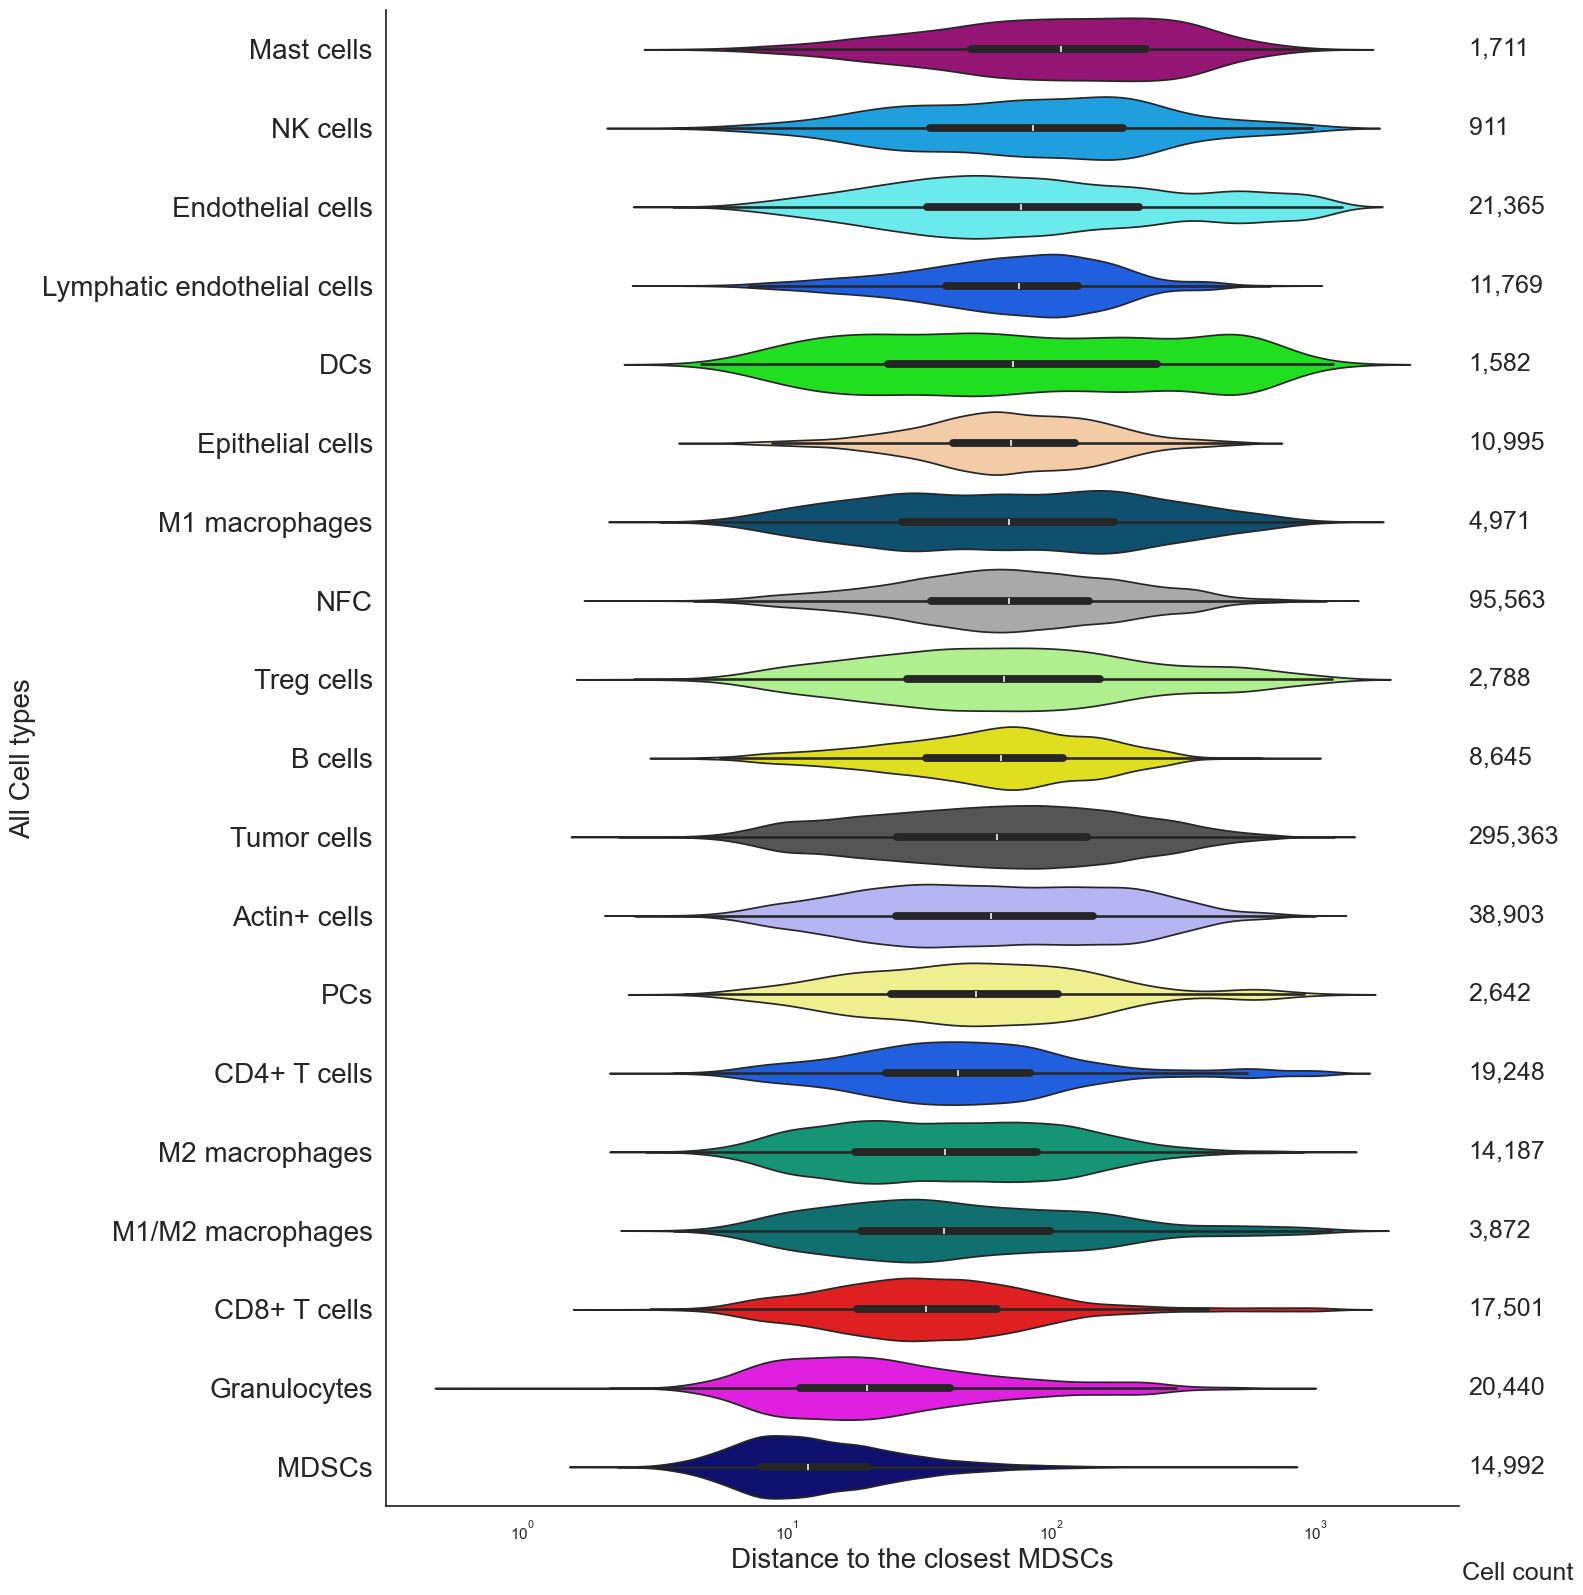

In [192]:
# --- Plot ---
fig, ax_violin = plt.subplots(figsize=(16, 16))

# Distance violinplot
sns.violinplot(
    data=distances,
    x="MDSCs",
    y="cell_category",
    order=order,
    palette=cell_category_color,   # <--- your custom colors here
    scale="width",
    ax=ax_violin,
    log_scale=True
)
#increase size of y-axis labels 
ax_violin.tick_params(axis='y', labelsize=20)
# Axis labels
ax_violin.set_xlabel(
    "Distance to the closest MDSCs",
    fontsize=20
)
ax_violin.set_ylabel(
    "All Cell types",
    fontsize=20
)

# Add counts on the right side
for i, cell_category in enumerate(order):
    count_val = counts[cell_category]
    ax_violin.text(
        x=ax_violin.get_xlim()[1] * 1.09,
        y=i,
        s=f"{count_val:,}",
        va="center",
        ha="left",
        fontfamily="Arial",
        fontsize = 18
    )

# Add label for counts (once)
ax_violin.text(
    x=ax_violin.get_xlim()[1] * 1.03,
    y=len(order) + 0.5,
    s="Cell count",
    va="bottom", ha="left",
    fontfamily="Arial", 
    fontsize = 18
)

# Remove right/top spines
sns.despine(ax=ax_violin, right=True, top=True)

#save svg figure
plt.tight_layout()
plt.show()